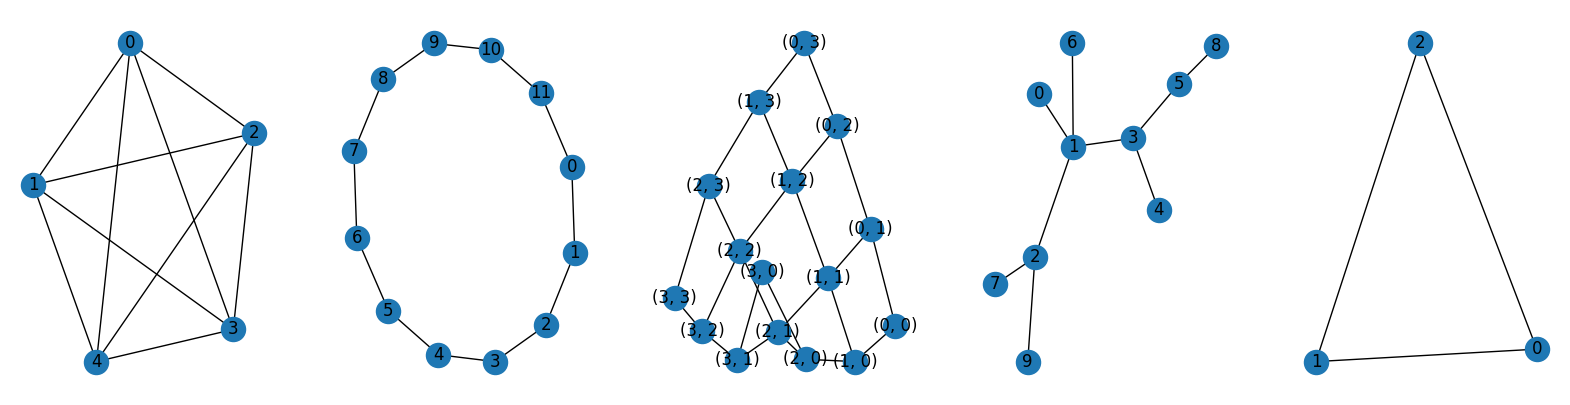

In [58]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# generate graphs
k3 = nx.complete_graph(3)
k5 = nx.complete_graph(5)
cycle = nx.cycle_graph(12)
grid = nx.grid_2d_graph(4, 4)
barb = nx.barabasi_albert_graph(10, 1)


# store in list
graphs = [k5, cycle, grid, barb, k3]

# subplot so all graphs can be displayed
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# loop through list of graphs and draw
for ax, G in zip(axes, graphs):
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, ax=ax, with_labels=True)

plt.show()

In [59]:
# enter graph for experiment
selected_graph = grid

# input number of colours for the topology
if selected_graph is k5:
    num_colours = 5
elif selected_graph is k3:
    num_colours = 3
else:
    num_colours = 2

palette = ["red", "blue", "green", "orange", "yellow"]

''' 
simple conflict counting function
reads node colours and returns count of edges with same colour at eaxh end
'''
def count_conflicts(graph, colouring):
    conflicts = 0
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicts += 1
    return conflicts

'''
record of conficting nodes
store node pairs that are coflicting in the 'conflicting' set
'''
def conflicting_nodes(graph, colouring):
    conflicting = set()
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicting.add(u)
            conflicting.add(v)
    return conflicting

In [60]:
# minimum conflict search experiment

max_steps = 200
num_runs = 20

def run_experiment(graph):

    # randomly colour graph using num_colours
    colouring = {node: random.randint(0, num_colours - 1) for node in graph.nodes()}

    # record number of conflicts through iterations
    conflicts_over_time = [count_conflicts(graph, colouring)]

    # loop for conflict minimising
    for _ in range(max_steps):

        current_conflicts = conflicts_over_time[-1]

        # break when solution is found
        if current_conflicts == 0:
            break

        # pick a conflicting node at randon
        bad_nodes = list(conflicting_nodes(graph, colouring))
        node = random.choice(bad_nodes)

        # store current colour and conflicts to compare with new colour choice 
        current_colour = colouring[node]
        best_colour = current_colour
        best_conflicts = current_conflicts

        # cycle through colours to find one that minimises conflicts
        for c in range(num_colours):

            colouring[node] = c

            # count conflicts for new colour
            new_conflicts = count_conflicts(graph, colouring)

            # update best colour and conflict count based on colours performance
            if new_conflicts < best_conflicts:
                best_conflicts = new_conflicts
                best_colour = c
        
        # record conflict count for best colour and update colouring
        colouring[node] = best_colour
        conflicts_over_time.append(count_conflicts(graph, colouring))

    return colouring, conflicts_over_time

Successes: 20 / 20
Final conflicts: 0


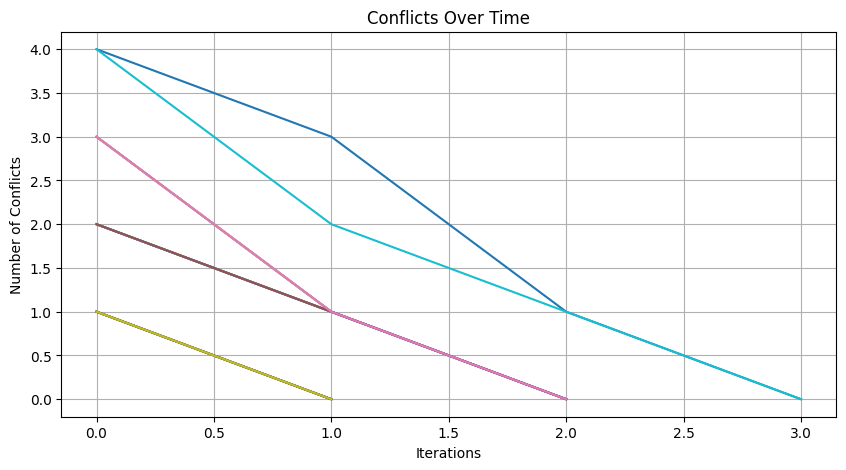

Successes: 2 / 20
Final conflicts: 0


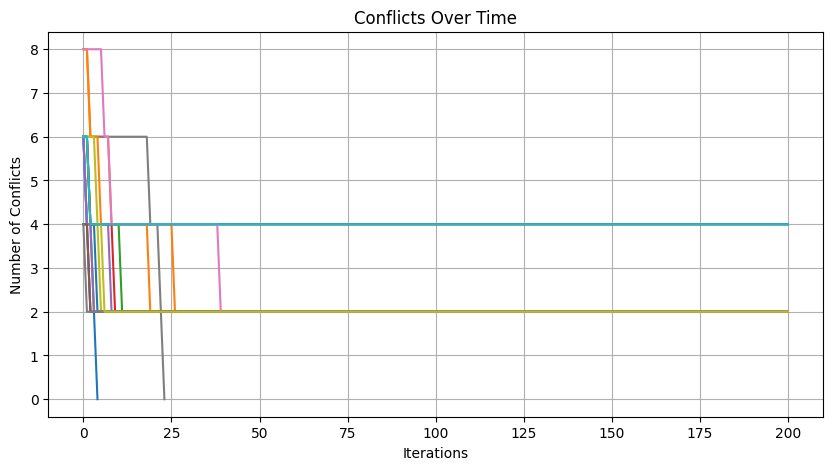

Successes: 8 / 20
Final conflicts: 0


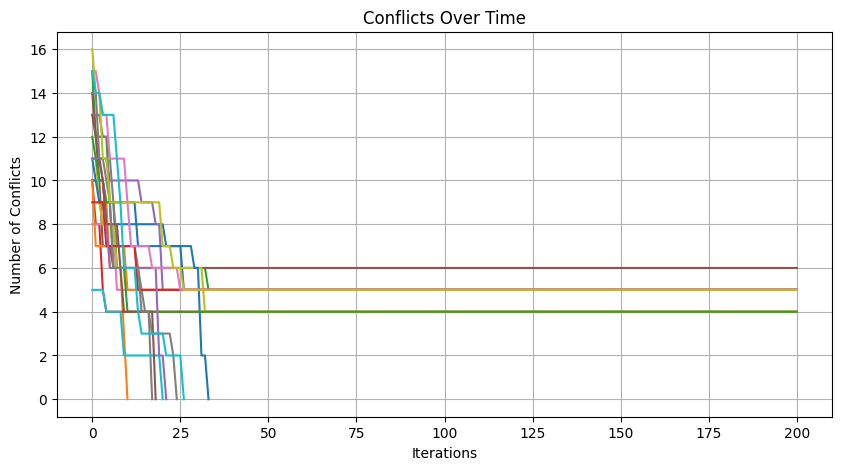

Successes: 8 / 20
Final conflicts: 0


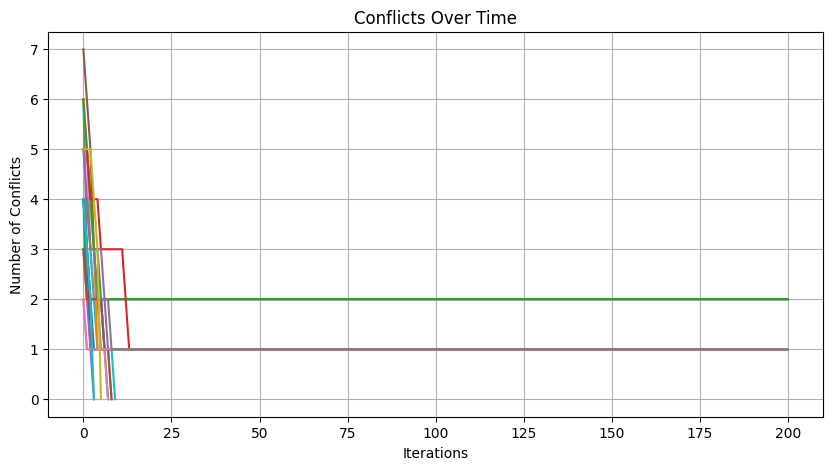

Successes: 20 / 20
Final conflicts: 0


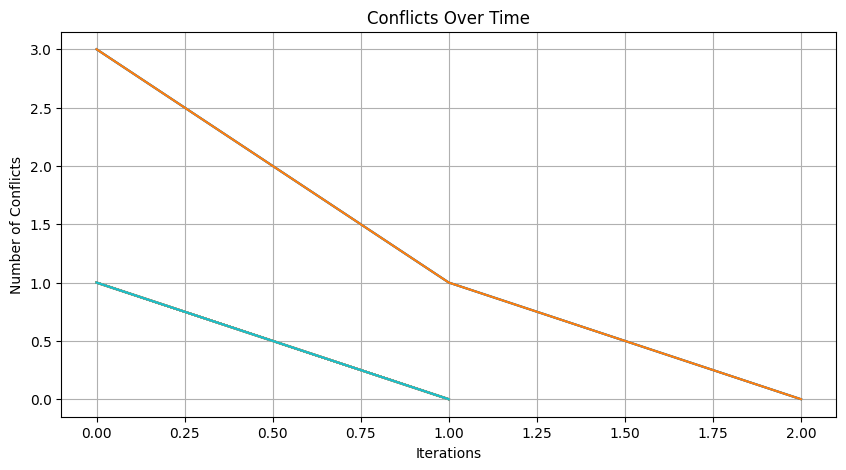

Total Rate of success over full experiment: 0.58


In [62]:
   
r = 1
total_success_rate = 0
loop_count = 0

for r in range(1,2):
     # loop through the graphs for easier comparison
    for selected_graph in graphs:
        if selected_graph is k5:
            num_colours = 5
        elif selected_graph is k3:
            num_colours = 3
        else:
            num_colours = 2


        all_conflicts = []
        end_conflicts = []
        steps_to_solution = []
        solutions = []

        for i in range(num_runs):
            colouring, conflicts_over_time = run_experiment(selected_graph)
            all_conflicts.append(conflicts_over_time)
            end_conflicts.append(conflicts_over_time[-1])
            steps_to_solution.append(len(conflicts_over_time) - 1)
            solutions.append(colouring)

        successes = sum(1 for c in end_conflicts if c == 0)

        # choose a solved run if one exists, otherwise choose the best run
        if successes > 0:
            index = next(i for i, conflicts in enumerate(end_conflicts) if conflicts == 0)
        else:
            index = min(range(len(end_conflicts)), key=lambda i: end_conflicts[i])

        # store solution
        sample_colouring = solutions[index]

        # convert colour indices to colour names for plotting
        node_colours_plot = [
            palette[sample_colouring[n]]
            for n in selected_graph.nodes()
        ]

        # plot graph
    
        print("Successes:", successes, "/", num_runs)
        print("Final conflicts:", end_conflicts[index])

        # keep an accumulative score of algo success rate across all graph runs
        total_success_rate += (successes / (num_runs))

        # plot conflict over time for runs
        plt.figure(figsize=(10, 5))
        for conflicts in all_conflicts:
            plt.plot(conflicts)

        plt.title("Conflicts Over Time")
        plt.xlabel("Iterations")
        plt.ylabel("Number of Conflicts")
        plt.grid(True)
        plt.show()

        
        loop_count += 1

# print algorithms overall performance over full experiment
overall_sr = total_success_rate / (loop_count)
#print("Total success Rate:", total_success_rate, "Loop Count:", loop_count)
print(f"Total Rate of success over full experiment:", str(round(overall_sr,4)))
